In [13]:
import re
from collections import Counter

# читаем файл
with open("lotr-word-cloud/1_The_Fellowship_Of_The_Ring/The_Fellowship_Of_The_Ring.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

# чистка текста
text = re.sub(r'[^a-z\s]', '', text)

# токенизация
words = text.split()

# удалим редкие слова (опционально)
vocab = Counter(words)
words = [w for w in words if vocab[w] > 5]

# словари
word2idx = {w: i for i, w in enumerate(set(words))}
idx2word = {i: w for w, i in word2idx.items()}

In [14]:
window_size = 2
pairs = []

for i, word in enumerate(words):
    center = word2idx[word]

    for j in range(-window_size, window_size + 1):
        if j == 0 or i + j < 0 or i + j >= len(words):
            continue
        
        context = word2idx[words[i + j]]
        pairs.append((center, context))

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.output = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.output(x)
        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
vocab_size = len(word2idx)
model = SkipGram(vocab_size, 100).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 256

for epoch in range(5):
    total_loss = 0

    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]

        centers = torch.tensor([p[0] for p in batch]).to(device)
        contexts = torch.tensor([p[1] for p in batch]).to(device)

        output = model(centers)
        loss = loss_fn(output, contexts)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(pairs):.4f}")

cuda
Epoch 1, Loss: 0.0247
Epoch 2, Loss: 0.0227
Epoch 3, Loss: 0.0223
Epoch 4, Loss: 0.0222
Epoch 5, Loss: 0.0220


In [18]:
import torch.nn.functional as F

def get_similar_words(word, top_k=5):
    if word not in word2idx:
        return []

    idx = word2idx[word]
    embeddings = model.embedding.weight.data

    word_vec = embeddings[idx]

    similarities = F.cosine_similarity(word_vec.unsqueeze(0), embeddings)

    top_idxs = similarities.argsort(descending=True)[1:top_k+1]

    return [idx2word[i.item()] for i in top_idxs]

In [19]:
print(get_similar_words("ring"))

['river', 'sauron', 'direction', 'twelve', 'burden']


In [20]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.linear = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = self.linear(x)
        return x

In [21]:
window_size = 2
cbow_data = []

for i in range(window_size, len(words) - window_size):
    context = []
    
    for j in range(-window_size, window_size + 1):
        if j != 0:
            context.append(word2idx[words[i + j]])

    target = word2idx[words[i]]
    cbow_data.append((context, target))

In [9]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model_cbow = CBOW(vocab_size, 100).to(device)

optimizer = optim.Adam(model_cbow.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()

batch_size = 256

for epoch in range(5):
    total_loss = 0
    count = 0

    for i in range(0, len(cbow_data), batch_size):
        batch = cbow_data[i:i+batch_size]

        contexts = torch.tensor([x[0] for x in batch], dtype=torch.long).to(device)
        targets = torch.tensor([x[1] for x in batch], dtype=torch.long).to(device)

        output = model_cbow(contexts)
        loss = loss_fn(output, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        count += 1

    print(f"CBOW Epoch {epoch + 1}, Loss: {total_loss / count:.4f}")

Using: cuda
CBOW Epoch 1, Loss: 6.4620
CBOW Epoch 2, Loss: 5.5943
CBOW Epoch 3, Loss: 5.3055
CBOW Epoch 4, Loss: 5.1175
CBOW Epoch 5, Loss: 4.9759


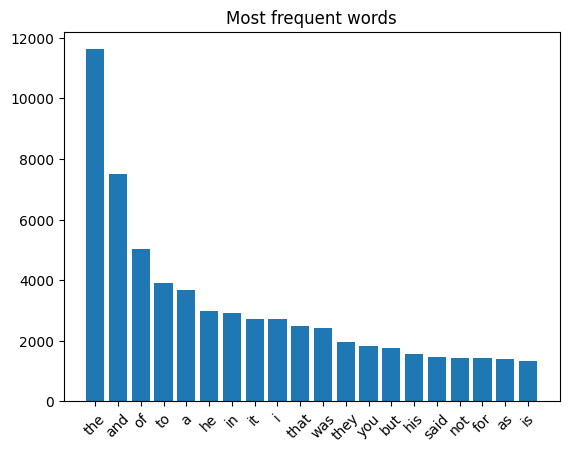

In [10]:
import matplotlib.pyplot as plt

common_words = Counter(words).most_common(20)

labels = [w[0] for w in common_words]
values = [w[1] for w in common_words]

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Most frequent words")
plt.show()

In [12]:
model = model_cbow
print("Similar to 'ring':", get_similar_words("ring"))

Similar to 'ring': ['strangers', 'came', 'relieved', 'hundred', 'aware']


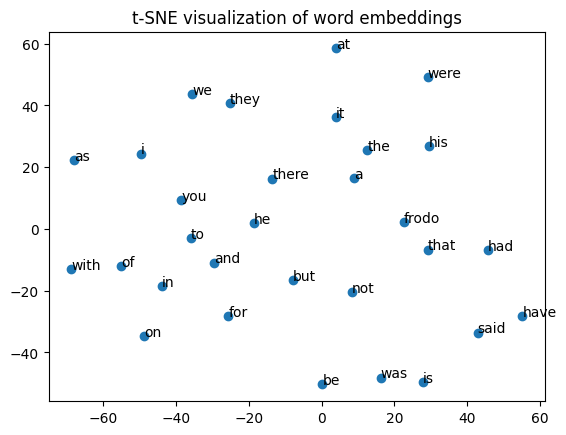

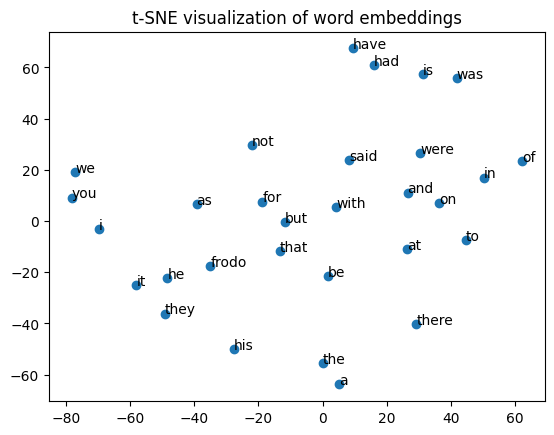

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne(model, word2idx, idx2word, top_n=30):
    from collections import Counter
    common_words = [w for w, _ in Counter(words).most_common(top_n)]
    
    indices = [word2idx[w] for w in common_words]

    embeddings = model.embedding.weight.data.cpu().numpy()
    selected_embeddings = embeddings[indices]

    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    reduced = tsne.fit_transform(selected_embeddings)

    plt.figure()

    x = reduced[:, 0]
    y = reduced[:, 1]

    plt.scatter(x, y)

    for i, word in enumerate(common_words):
        plt.annotate(word, (x[i], y[i]))

    plt.title("t-SNE visualization of word embeddings")
    plt.show()

plot_tsne(model, word2idx, idx2word)        # Skip-gram
plot_tsne(model_cbow, word2idx, idx2word)   # CBOW